#  Hyperspectral Image Classification



# Download Dataset from KaggleHub

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rupeshkumaryadav/whu-hyperspectral-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/rupeshkumaryadav/whu-hyperspectral-dataset


# Install & Import Libraries

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import warnings
warnings.filterwarnings('ignore')
import matplotlib as mpl
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'kagglehub', '-q'])

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', 'kagglehub', '-q'], returncode=0)

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Load the Data

In [5]:
# Find and load the .mat files

mat_files_found = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".mat"):
            mat_files_found.append(os.path.join(root, file))

print(f'Found {len(mat_files_found)} data files.')

# Initialize an empty dictionary to hold all data
combined_data = {}

# Load each .mat file and merge its contents
for mat_path in mat_files_found:
    try:
        current_data = sio.loadmat(mat_path)
        combined_data.update(current_data)
        print(f"Loaded: {mat_path}")
    except Exception as e:
        print(f"Error loading {mat_path}: {e}")

data = combined_data # Use combined_data for subsequent processing

print('\nKeys inside the combined data: ')

for k, v in data.items():
    if not k.startswith('__'):
        print(f'{k:30s} to shape {v.shape if hasattr(v,"shape") else type(v)}')


Found 48 data files.
Loaded: /kaggle/input/datasets/rupeshkumaryadav/whu-hyperspectral-dataset/WHU-Hi-LongKou/WHU_Hi_LongKou_gt.mat
Loaded: /kaggle/input/datasets/rupeshkumaryadav/whu-hyperspectral-dataset/WHU-Hi-LongKou/WHU_Hi_LongKou.mat
Loaded: /kaggle/input/datasets/rupeshkumaryadav/whu-hyperspectral-dataset/WHU-Hi-LongKou/Training samples and test samples/Test25.mat
Loaded: /kaggle/input/datasets/rupeshkumaryadav/whu-hyperspectral-dataset/WHU-Hi-LongKou/Training samples and test samples/Train250.mat
Loaded: /kaggle/input/datasets/rupeshkumaryadav/whu-hyperspectral-dataset/WHU-Hi-LongKou/Training samples and test samples/Train100.mat
Loaded: /kaggle/input/datasets/rupeshkumaryadav/whu-hyperspectral-dataset/WHU-Hi-LongKou/Training samples and test samples/Test250.mat
Loaded: /kaggle/input/datasets/rupeshkumaryadav/whu-hyperspectral-dataset/WHU-Hi-LongKou/Training samples and test samples/Test300.mat
Loaded: /kaggle/input/datasets/rupeshkumaryadav/whu-hyperspectral-dataset/WHU-Hi-Lon

## Auto-detect the image cube and label map

In [6]:
hsi_cube = None # (H, W, B) float array
gt_map = None # (H, W)    int array

## Keys commonly used in hyperspectral .mat files

In [7]:
cube_key = ['data', 'image', 'img', 'hsi', 'WHU_Hi_HanChuan','WHU_Hi_LongKou',
            'WHU_Hi_HongHu', 'cube', 'X', 'HSI']

In [8]:
label_keys = ['gt', 'groundtruth', 'ground_truth', 'labels',
               'label', 'GT', 'map', 'y', 'Y', 'WHU_Hi_LongKou_gt']

In [9]:
for key in cube_key:
    if data and key in data and hasattr(data[key], 'shape'):
        arr = data[key]
        if len(arr.shape) == 3:
            hsi_cube = arr.astype(np.float32)
            print(f'Found hyperspectral cube with shape {hsi_cube.shape}')
            break

Found hyperspectral cube with shape (1217, 303, 274)


In [10]:
for key in label_keys:
     if data and key in data and hasattr(data[key], 'shape'):
        arr = data[key]
        if arr.ndim == 2:
          gt_map = arr.astype(np.int32)
          print(f'Found Ground-truth labels with shape {gt_map.shape}')

Found Ground-truth labels with shape (550, 400)


## pick largest 3-D array as cube, largest 2-D as gt

In [11]:
if hsi_cube is None:
    candidates = [(k,v) for k,v in data.items()
                  if not k.startswith('_') and hasattr(v,'ndim') and v.ndim==3]
    if candidates:
        k,v = max(candidates, key=lambda x: x[1].size)
        hsi_cube = v.astype(np.float32)
        print(f'Cube (fallback) to "{k}"shape={hsi_cube.shape}')

if gt_map is None:
    candidates = [(k,v) for k,v in data.items()
                  if not k.startswith('_') and hasattr(v,'ndim') and v.ndim==2]
    if candidates:
        k,v = max(candidates, key=lambda x: x[1].size)
        gt_map = v.astype(np.int32)
        print(f' GT (fallback) to "{k}"shape={gt_map.shape}')

## If bands is first dimension, swap to (H, W, B)

In [12]:
if hsi_cube.shape[0] < hsi_cube.shape[2]:
    hsi_cube = np.transpose(hsi_cube, (1, 2, 0))

H, W, B = hsi_cube.shape
classes = np.unique(gt_map[gt_map > 0])
n_classes = len(classes)

print(f'\nDataset Info')
print(f'Image size : {H} rows × {W} columns')
print(f'Spectral bands: {B}')
print(f'Number of classes: {n_classes}')


Dataset Info
Image size : 1217 rows × 303 columns
Spectral bands: 274
Number of classes: 9


# Visualise the Data

In [13]:
#classes nice names (works for most WHU datasets)
WHU_NAMES = {
    9:  ['Corn','Cotton','Sesame','Broad-leaf Soybean','Narrow-leaf Soybean',
         'Rice','Water','Roads & Buildings','Mixed Weed'],
    16: ['Strawberry','Cowpea','Soybean','Sorghum','Water Spinach',
         'Watermelon','Greens','Trees','Grass','Red Roof',
         'Gray Roof','Plastic','Bare Soil','Road','Bright Object','Water'],
}

In [14]:
class_names = WHU_NAMES.get(n_classes, [f'Class {i}' for i in range(1, n_classes+1)])
print('Class names:', class_names)

Class names: ['Corn', 'Cotton', 'Sesame', 'Broad-leaf Soybean', 'Narrow-leaf Soybean', 'Rice', 'Water', 'Roads & Buildings', 'Mixed Weed']


# Show false-colour image and label map side by side

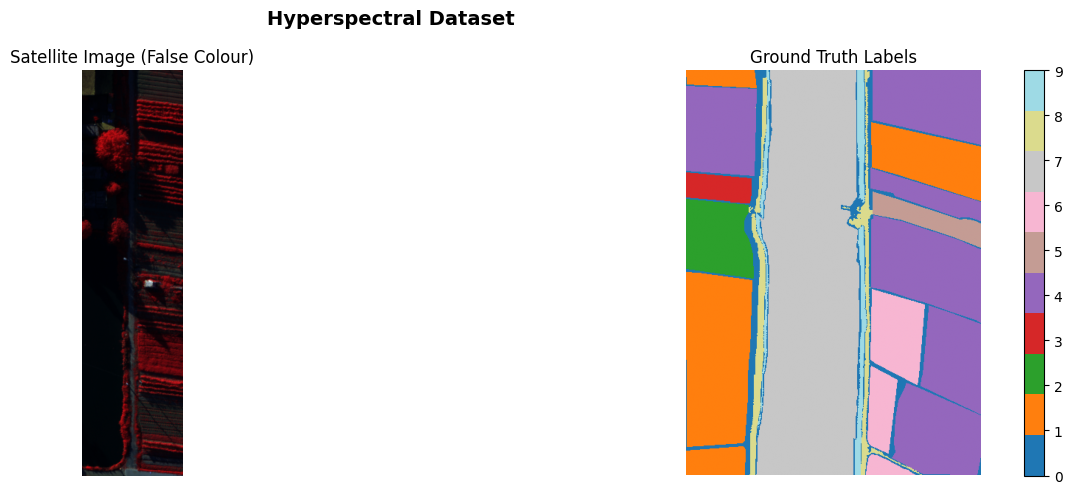

Images displayed


In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hyperspectral Dataset', fontsize=14, fontweight='bold')

# False colour: pick 3 bands for Red, Green, Blue
r = hsi_cube[:, :, int(B*0.75)]
g = hsi_cube[:, :, int(B*0.45)]
b = hsi_cube[:, :, int(B*0.15)]
def norm(x): return (x - x.min()) / (x.max() - x.min() + 1e-8)
rgb = np.stack([norm(r), norm(g), norm(b)], axis=2)

ax1.imshow(rgb)
ax1.set_title('Satellite Image (False Colour)', fontsize=12)
ax1.axis('off')

# --- CHANGED THIS LINE ---
cmap = plt.colormaps['tab20'].resampled(n_classes + 1)
# -------------------------

im = ax2.imshow(gt_map, cmap=cmap)
ax2.set_title('Ground Truth Labels', fontsize=12)
ax2.axis('off')
plt.colorbar(im, ax=ax2, fraction=0.04)

plt.tight_layout()
plt.show()
print('Images displayed')


# Prepare Training Data (Cut Image into Small Patches)

## Reduce spectral redundancy with PCA (before normalisation)

In [16]:
from sklearn.decomposition import PCA

# Hyperspectral bands are highly correlated with each other and noisy.
# PCA compresses them into a smaller set of decorrelated components,
# which reduces noise/redundancy the model has to learn through and
# speeds up training. This is standard practice for spectral-spatial
# CNNs like this one (3D conv over bands + 2D conv over space).
N_COMPONENTS = min(30, B)

flat_cube = hsi_cube.reshape(-1, B)
pca = PCA(n_components=N_COMPONENTS, random_state=42)
flat_pca = pca.fit_transform(flat_cube)

hsi_cube = flat_pca.reshape(H, W, N_COMPONENTS)
print(f'Reduced spectral bands from {B} to {N_COMPONENTS} PCA components')
print(f'Variance explained: {pca.explained_variance_ratio_.sum()*100:.2f}%')

B = N_COMPONENTS


Reduced spectral bands from 274 to 30 PCA components
Variance explained: 99.78%


In [17]:
# Normalise each spectral band independently (0 to 1)
# Bands can have very different value ranges, so a single global min/max
# under- or over-scales some bands. Per-band scaling gives the network
# comparable input ranges across all bands, which speeds up and stabilises training.
band_min = hsi_cube.min(axis=(0, 1), keepdims=True)
band_max = hsi_cube.max(axis=(0, 1), keepdims=True)
cube = (hsi_cube - band_min) / (band_max - band_min + 1e-8)

PATCH   = 15   # bigger spatial context per patch (was 9) -> more neighbourhood
                # information for the model to disambiguate similar spectra
PAD     = PATCH // 2
MAX_PER_CLASS = 1000   # more training samples per class (was 600)


In [18]:
# Pad the image so we can cut patches near the edges
cube_padded = np.pad(cube, ((PAD,PAD),(PAD,PAD),(0,0)), mode='reflect')

In [19]:
patches = [] # All the small image patches
labels  = [] # class label for each patch

for cls_idx, cls in enumerate(classes):
    rows, cols = np.where(gt_map == cls) # find all pixels of this class


    # randomly pick MAX_PER_CLASS pixels
    if len(rows) > MAX_PER_CLASS:
        idx = np.random.choice(len(rows), MAX_PER_CLASS, replace=False)
        rows, cols = rows[idx], cols[idx]


    for r, c in zip(rows, cols):
        patch = cube_padded[r : r+PATCH, c : c+PATCH, :]  # cut 9×9 patch
        patches.append(patch)
        labels.append(cls_idx)            # 0-based class index

In [20]:
expected_patch_shape = (PATCH, PATCH, B)
filtered_patches = []
filtered_labels = []

for i, patch in enumerate(patches):
    if patch.shape == expected_patch_shape:
        filtered_patches.append(patch)
        filtered_labels.append(labels[i])
    else:
        pass

if not filtered_patches:
    raise ValueError("No valid patches found after filtering. Check hsi_cube and gt_map alignment.")

X = np.array(filtered_patches, dtype=np.float32)  # shape: (N, 9, 9, B)
y = np.array(filtered_labels,  dtype=np.int32)

print(f'Created {len(X)} training patches')
print(f'Each patch shape: {X.shape[1:]}')
print(f'Classes: {n_classes}')

Created 7357 training patches
Each patch shape: (15, 15, 30)
Classes: 9


# Split Data into Train / Validation / Test

In [21]:
# Convert labels to one-hot format
y_onehot = to_categorical(y, num_classes=n_classes)

In [22]:
# 70% train, 15% validation, 15% test

X_tv, X_test, y_tv, y_test = train_test_split(
    X, y_onehot, test_size=0.15, random_state=42, stratify=y)

In [23]:
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.176, random_state=42,
    stratify=np.argmax(y_tv, axis=1))

## Augment the training patches (flips & rotation)

In [24]:
# Augment TRAINING patches only (never val/test, to avoid leaking info).
# Land-cover patches are label-invariant to flips/rotation, so this cheaply
# multiplies the effective training set and helps the model generalise,
# which matters here since samples per class are capped at MAX_PER_CLASS.
def augment_patches(X, y):
    variants = [
        X,
        np.flip(X, axis=1),                 # vertical flip
        np.flip(X, axis=2),                 # horizontal flip
        np.rot90(X, k=1, axes=(1, 2)),       # 90 deg
        np.rot90(X, k=2, axes=(1, 2)),       # 180 deg
        np.rot90(X, k=3, axes=(1, 2)),       # 270 deg
    ]
    X_aug = np.concatenate(variants, axis=0)
    y_aug = np.concatenate([y] * len(variants), axis=0)
    return X_aug, y_aug

X_train, y_train = augment_patches(X_train, y_train)

# shuffle so augmented copies aren't grouped together in batches
perm = np.random.permutation(len(X_train))
X_train, y_train = X_train[perm], y_train[perm]

print(f'Training samples after augmentation: {len(X_train)}')


Training samples after augmentation: 30912


In [25]:
# Add channel dimension for the model  (N, 9, 9, B) to (N, 9, 9, B, 1)
X_train = X_train[..., np.newaxis]
X_val   = X_val[...,   np.newaxis]
X_test  = X_test[...,  np.newaxis]

print(f'Training   samples: {len(X_train)}')
print(f'Validation samples: {len(X_val)}')
print(f'Test       samples: {len(X_test)}')

Training   samples: 30912
Validation samples: 1101
Test       samples: 1104


# Build the Deep Learning Model

In [26]:
def build_model(patch, bands, num_classes):
    inp = layers.Input(shape=(patch, patch, bands, 1))

    # --- Feature extraction with 3D convolutions ---
    x = layers.Conv3D(32, (3,3,7), padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)

    x = layers.Conv3D(64, (3,3,5), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    # Flatten the band dimension
    sh = x.shape
    x = layers.Reshape((sh[1], sh[2], sh[3]*sh[4]))(x)

    # --- 2D spatial convolution ---
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    # --- Classifier head ---
    x = layers.GlobalAveragePooling2D()(x)  # compress to a 1D vector
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)              # randomly drop neurons to reduces overfitting
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)  # final class probabilities

    return models.Model(inputs=inp, outputs=out)

model = build_model(PATCH, B, n_classes)



model.summary()

I0000 00:00:1789693659.449746      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789693659.452663      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 15, 15, 30, 1)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d (Conv3D)                 │ (None, 15, 15, 30, 32) │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 15, 15, 30, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 15, 15, 30, 64) │        92,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15, 15, 30, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 15, 15, 1920)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 15, 15, 128)    │     2,211,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 15, 15, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,374,217 (9.06 MB)

 Trainable params: 2,373,769 (9.06 MB)

 Non-trainable params: 448 (1.75 KB)

In [27]:
# Compile the model
model.compile(
    optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

# Train the Model

In [28]:
# Early Stopping: stop if val_accuracy doesn't improve for 15 epochs
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

In [29]:
# Reduce Learning Rate
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    verbose=1
)

## Class weights (helps under-represented classes)

In [30]:
from sklearn.utils.class_weight import compute_class_weight

# Some classes may naturally have far fewer than MAX_PER_CLASS pixels,
# so the training set can still be imbalanced. Weighting the loss by
# class frequency helps the model not ignore rarer classes.
y_train_int = np.argmax(y_train, axis=1)
weights = compute_class_weight('balanced', classes=np.unique(y_train_int), y=y_train_int)
class_weight_dict = dict(zip(np.unique(y_train_int).tolist(), weights))
print('Class weights:', {k: round(v,2) for k, v in class_weight_dict.items()})


Class weights: {0: np.float64(1.01), 1: np.float64(0.82), 2: np.float64(0.82), 3: np.float64(2.1), 4: np.float64(2.56), 5: np.float64(0.97), 6: np.float64(0.82), 7: np.float64(0.82), 8: np.float64(0.82)}


In [33]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_acc = max(history.history['val_accuracy']) * 100


print(f'\nTraining done!')
print(f'Best epoch: {best_epoch} and Best Val Accuracy: {best_acc:.2f}%')

Epoch 1/100
483/483 ━━━━━━━━━━━━━━━━━━━━ 66s 137ms/step - accuracy: 0.9171 - loss: 0.2111 - val_accuracy: 0.4496 - val_loss: 5.1650 - learning_rate: 0.0010
Epoch 2/100
483/483 ━━━━━━━━━━━━━━━━━━━━ 66s 136ms/step - accuracy: 0.9224 - loss: 0.1956 - val_accuracy: 0.7920 - val_loss: 0.6371 - learning_rate: 0.0010
Epoch 3/100
483/483 ━━━━━━━━━━━━━━━━━━━━ 65s 135ms/step - accuracy: 0.9245 - loss: 0.1884 - val_accuracy: 0.5622 - val_loss: 3.7409 - learning_rate: 0.0010
Epoch 4/100
483/483 ━━━━━━━━━━━━━━━━━━━━ 65s 135ms/step - accuracy: 0.9311 - loss: 0.1765 - val_accuracy: 0.6685 - val_loss: 1.2004 - learning_rate: 0.0010
Epoch 5/100
483/483 ━━━━━━━━━━━━━━━━━━━━ 65s 135ms/step - accuracy: 0.9344 - loss: 0.1699 - val_accuracy: 0.6385 - val_loss: 2.0177 - learning_rate: 0.0010
Epoch 6/100
483/483 ━━━━━━━━━━━━━━━━━━━━ 65s 135ms/step - accuracy: 0.9393 - loss: 0.1498 - val_accuracy: 0.7230 - val_loss: 1.2072 - learning_rate: 0.0010
Epoch 7/100
483/483 ━━━━━━━━━━━━━━━━━━━━ 65s 135ms/step - accura

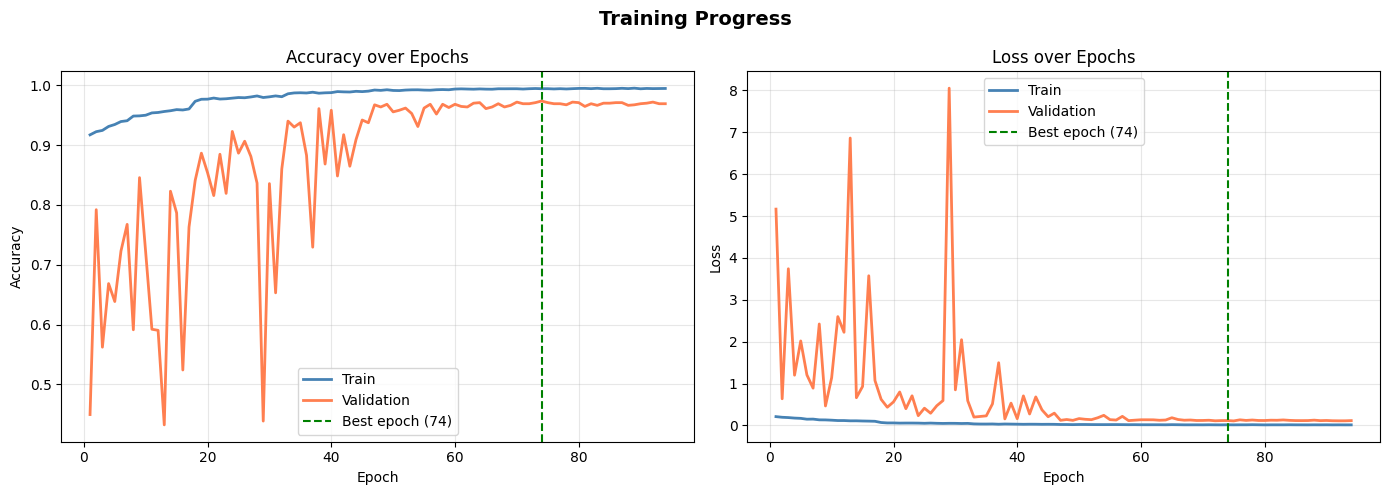

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Progress', fontsize=14, fontweight='bold')

epochs_ran = range(1, len(history.history['accuracy']) + 1)

# Accuracy plot
ax1.plot(epochs_ran, history.history['accuracy'],     label='Train', color='steelblue', linewidth=2)
ax1.plot(epochs_ran, history.history['val_accuracy'], label='Validation', color='coral', linewidth=2)
ax1.axvline(best_epoch, color='green', linestyle='--', label=f'Best epoch ({best_epoch})')
ax1.set_title('Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(alpha=0.3)


# Loss plot
ax2.plot(epochs_ran, history.history['loss'],     label='Train', color='steelblue', linewidth=2)
ax2.plot(epochs_ran, history.history['val_loss'], label='Validation', color='coral', linewidth=2)
ax2.axvline(best_epoch, color='green', linestyle='--', label=f'Best epoch ({best_epoch})')
ax2.set_title('Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Test the Model

In [36]:
# Evaluate on the test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy: {test_acc*100:.2f}%')
print(f'Test Loss: {test_loss:.4f}')

Test Accuracy: 96.92%
Test Loss: 0.1487


In [38]:
# Detailed report
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
y_true = np.argmax(y_test, axis=1)

In [39]:
print('\nPer-class Results:')
print(classification_report(y_true, y_pred,
      target_names=class_names[:n_classes], zero_division=0))


Per-class Results:
                     precision    recall  f1-score   support

               Corn       0.99      0.99      0.99       121
             Cotton       1.00      1.00      1.00       150
             Sesame       0.99      1.00      1.00       150
 Broad-leaf Soybean       0.92      0.95      0.93        59
Narrow-leaf Soybean       1.00      1.00      1.00        48
               Rice       0.98      0.99      0.98       127
              Water       1.00      0.91      0.95       150
  Roads & Buildings       0.92      0.94      0.93       149
         Mixed Weed       0.93      0.95      0.94       150

           accuracy                           0.97      1104
          macro avg       0.97      0.97      0.97      1104
       weighted avg       0.97      0.97      0.97      1104



# Confusion matrix — shows what the model confused

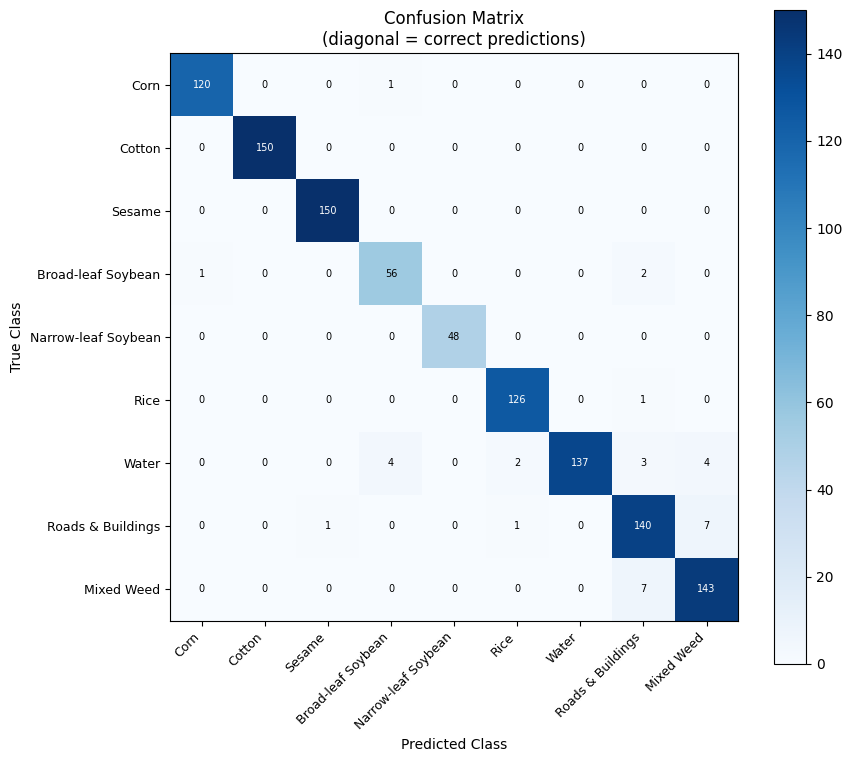

In [40]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(max(8, n_classes), max(7, n_classes-1)))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)

ax.set_xticks(range(n_classes))
ax.set_yticks(range(n_classes))
ax.set_xticklabels(class_names[:n_classes], rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(class_names[:n_classes], fontsize=9)
ax.set_xlabel('Predicted Class')
ax.set_ylabel('True Class')
ax.set_title('Confusion Matrix\n(diagonal = correct predictions)', fontsize=12)

thresh = cm.max() / 2
for i in range(n_classes):
    for j in range(n_classes):
        ax.text(j, i, cm[i,j], ha='center', va='center',
                color='white' if cm[i,j] > thresh else 'black',
                fontsize=max(6, 10 - n_classes//3))
plt.tight_layout()
plt.show()

In [41]:
import os

# Save trained model weights
save_path = '/kaggle/working/best_model.weights.h5'

model.save_weights(save_path)

print(f"Model weights saved to: {save_path}")

Model weights saved to: /kaggle/working/best_model.weights.h5
